In [1]:
!pip install -q "txtai[pipeline]" shap pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 998.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.8/233.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.5/731.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.5/203.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [2]:
from txtai.embeddings import Embeddings
import pandas as pd

#mesmas noticias da aula junto de manchetes em pt
data = [
    "US tops 5 million confirmed virus cases",
    "Canada's last fully intact ice shelf has suddenly collapsed, forming a Manhattan-sized iceberg",
    "Beijing mobilises invasion craft along coast as Taiwan tensions escalate",
    "The National Park Service warns against sacrificing slower friends in a bear attack",
    "Maine man wins $1M from $25 lottery ticket",
    "Make huge profits without work, earn up to $100,000 a day",
    "Governo confirma milhoes de casos de virus no pais",
    "Geleira historica no Canada desaba e forma iceberg gigante",
    "Tensao aumenta entre China e Taiwan apos movimentacao militar",
    "Aposentado ganha na loteria com bilhete premiado de R$25",
    "Ganhe dinheiro facil trabalhando de casa, R$10 mil por dia",
]

#modelo multilingue pra dar conta de en e pt na mesma base
embeddings = Embeddings({"path": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2", "content": True})
embeddings.index([(uid, text, None) for uid, text in enumerate(data)])

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Unzipping corpora/cmudict.zip.


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

...

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

In [3]:
#mesmo conceito em duas linguas, pra ver se a explicacao aponta pro mesmo tipo de palavra
embeddings.explain("feel good story", limit=1)

[{'id': '10',
  'text': 'Ganhe dinheiro facil trabalhando de casa, R$10 mil por dia',
  'score': 0.17341402173042297,
  'tokens': [('Ganhe', 0.025021404027938843),
   ('dinheiro', 0.008576169610023499),
   ('facil', 0.013818234205245972),
   ('trabalhando', -0.04353310167789459),
   ('de', -0.015345841646194458),
   ('casa,', 0.015260174870491028),
   ('R$10', -0.03845447301864624),
   ('mil', 0.00823250412940979),
   ('por', -0.015407249331474304),
   ('dia', -0.043137237429618835)]}]

In [4]:
embeddings.explain("noticia boa, sorte", limit=1)

[{'id': '10',
  'text': 'Ganhe dinheiro facil trabalhando de casa, R$10 mil por dia',
  'score': 0.20894062519073486,
  'tokens': [('Ganhe', 0.002132996916770935),
   ('dinheiro', 0.023470640182495117),
   ('facil', 0.01667313277721405),
   ('trabalhando', -0.073117196559906),
   ('de', -0.026855528354644775),
   ('casa,', -0.004207715392112732),
   ('R$10', -0.04905295372009277),
   ('mil', 0.005381673574447632),
   ('por', -0.019314706325531006),
   ('dia', -0.04104381799697876)]}]

In [5]:
from IPython.display import HTML

#mesma funcao de plot da aula, sem mudanca na logica de cor
def plot(query):
    result = embeddings.explain(query, limit=1)[0]
    output = f"<b>{query}</b><br/>"
    spans = []
    for token, score in result["tokens"]:
        color = None
        if score >= 0.1:
            color = "#fdd835"
        elif score >= 0.075:
            color = "#ffeb3b"
        elif score >= 0.05:
            color = "#ffee58"
        elif score >= 0.02:
            color = "#fff59d"
        spans.append((token, score, color))

    if result["score"] >= 0.05 and not [c for _, _, c in spans if c]:
        mscore = max(s for _, s, _ in spans)
        spans = [(t, s, "#fff59d" if s == mscore else c) for t, s, c in spans]

    for token, _, color in spans:
        output += f"<span style='background-color: {color}'>{token}</span> " if color else f"{token} "
    return output

HTML(plot("feel good story") + "<br/><br/>" + plot("noticia boa, sorte"))

In [7]:
#pares de query pt/en, pra comparar se o token mais importante muda de lingua pra lingua
queries = ["feel good story", "noticia boa, sorte", "war", "guerra", "wildlife", "vida selvagem", "dishonest junk", "golpe, dinheiro facil"]
resultados = embeddings.batchexplain(queries, limit=1)

#jogando tudo pra um dataframe, fica mais facil de agregar depois
linhas = []
for q, r in zip(queries, resultados):
    r = r[0]
    for token, score in r["tokens"]:
        linhas.append({"query": q, "id": r["id"], "token": token.lower(), "score": score})

df = pd.DataFrame(linhas)

#media do score de cada token
ranking_global = df.groupby("token")["score"].mean().sort_values(ascending=False)
print(ranking_global.head(15))

token
militar        0.124721
bear           0.099853
park           0.096482
national       0.039971
facil          0.035341
entre          0.032888
dinheiro       0.022480
against        0.018228
the            0.017450
na             0.014550
mil            0.013783
ganhe          0.013605
sacrificing    0.012745
slower         0.010565
bilhete        0.010555
Name: score, dtype: float64


In [9]:
#removendo os 2 melhores tokens juntos
def checa_aditividade(query, resultado):
    if len(resultado["tokens"]) < 2:
        return None

    texto = resultado["text"]
    top1, top2 = sorted(resultado["tokens"], key=lambda t: t[1], reverse=True)[:2]
    soma_individual = top1[1] + top2[1]

    palavras = texto.split()
    texto_sem_ambos = " ".join(p for p in palavras if p not in (top1[0], top2[0]))

    score_original = resultado["score"]
    score_sem_ambos = embeddings.similarity(query, [texto_sem_ambos])[0][1]
    delta_real = score_original - score_sem_ambos

    return top1[0], top2[0], soma_individual, delta_real

for q, r in zip(queries, resultados):
    resultado_check = checa_aditividade(q, r[0])
    if resultado_check:
        t1, t2, previsto, real = resultado_check
        print(f"{q:25s} tokens=({t1}, {t2}) soma_individual={previsto:.4f} delta_real={real:.4f}")

feel good story           tokens=(Ganhe, casa,) soma_individual=0.0403 delta_real=0.0418
noticia boa, sorte        tokens=(dinheiro, facil) soma_individual=0.0401 delta_real=0.0093
war                       tokens=(militar, entre) soma_individual=0.1620 delta_real=0.1673
guerra                    tokens=(militar, entre) soma_individual=0.1532 delta_real=0.1578
wildlife                  tokens=(bear, Park) soma_individual=0.2145 delta_real=0.3236
vida selvagem             tokens=(Park, bear) soma_individual=0.1781 delta_real=0.2965
dishonest junk            tokens=(na, bilhete) soma_individual=0.0251 delta_real=0.0227
golpe, dinheiro facil     tokens=(facil, dinheiro) soma_individual=0.1109 delta_real=0.0925


In [10]:
import shap
from txtai.pipeline import Labels

#modelo de sentimento multilingue
labels = Labels("cardiffnlp/twitter-xlm-roberta-base-sentiment", dynamic=False)

avaliacoes = [
    "Dodgers lose again, give up 3 HRs in a loss to the Giants",
    "Massive dunk!!! they are now up by 15 with 2 minutes to go",
    "Pessimo atendimento, nao recomendo a ninguem",
    "Adorei o produto, chegou rapido e funciona perfeitamente",
]

explainer = shap.Explainer(labels.pipeline)
shap_values = explainer(avaliacoes)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

...

PartitionExplainer explainer:  75%|███████▌  | 3/4 [02:06<00:20, 20.31s/it]

  0%|          | 0/156 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 4/4 [02:28<00:00, 20.84s/it]

  0%|          | 0/156 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [02:50, 42.50s/it]


In [11]:
shap.plots.text(shap_values[2, :, "negative"])

In [12]:
shap.plots.text(shap_values[3, :, "positive"])

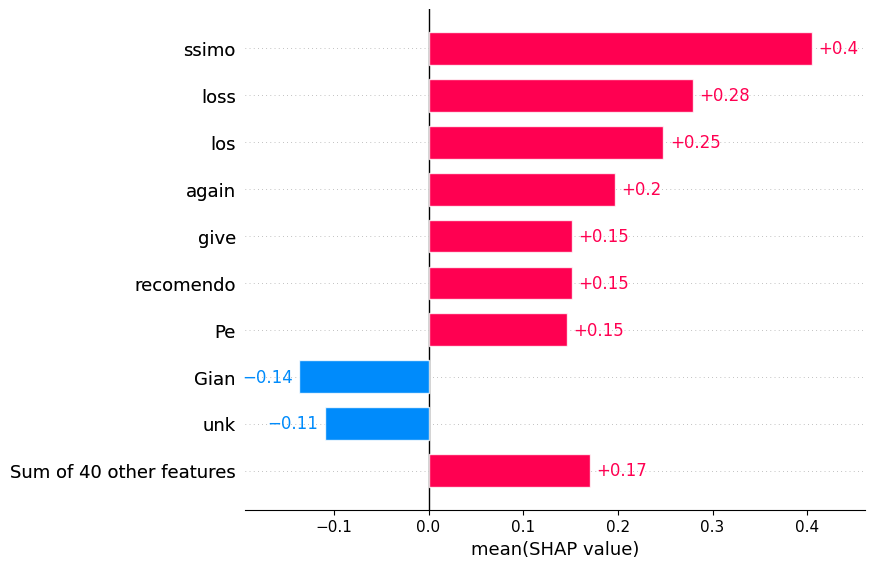

In [13]:
#media do impacto de cada token na classe negativa
shap.plots.bar(shap_values[:, :, "negative"].mean(0))

In [14]:
from transformers import pipeline
import numpy as np

#modelo de zero-shot, explicando a decisao com shap
zero_shot = pipeline("zero-shot-classification", model="joeddav/xlm-roberta-large-xnli")
categorias = ["futebol", "politica", "tecnologia"]

def zero_shot_scores(textos):
    saida = zero_shot(list(textos), candidate_labels=categorias)
    if isinstance(saida, dict):
        saida = [saida]
    matriz = [[dict(zip(s["labels"], s["scores"]))[c] for c in categorias] for s in saida]
    return np.array(matriz)

masker = shap.maskers.Text(zero_shot.tokenizer)
explainer_zs = shap.Explainer(zero_shot_scores, masker, output_names=categorias)

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [15]:
textos_zs = [
    "O time perdeu de virada nos ultimos minutos da partida",
    "O governo anunciou um novo pacote de medidas economicas",
]

shap_values_zs = explainer_zs(textos_zs)
shap.plots.text(shap_values_zs[0, :, "futebol"])

  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 1/2 [00:00<?, ?it/s]

  0%|          | 0/132 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [08:08, 244.40s/it]


In [16]:
shap.plots.text(shap_values_zs[1, :, "politica"])

In [17]:
#compara o top 5 da ablacao global com o top 5 em |valor shap| de uma frase negativa, so pra ver se a natureza dos dois bate
print("top ablacao (embeddings.explain):")
print(ranking_global.head(5))

shap_exp = shap_values[2, :, "negative"]
shap_abs = pd.Series(np.abs(shap_exp.values), index=shap_exp.data).sort_values(ascending=False)
print("\ntop |shap| (frase negativa em pt):")
print(shap_abs.head(5))

top ablacao (embeddings.explain):
token
militar     0.124721
bear        0.099853
park        0.096482
national    0.039971
facil       0.035341
Name: score, dtype: float64

top |shap| (frase negativa em pt):
ssimo         0.404721
recomendo     0.151134
Pe            0.146604
na            0.099729
a             0.087903
dtype: float64
